# PETROL PRICE PREDICTION

---

## PROBLEM STATEMENT

Analyze how factors such as country, region, subsidy level, Brent crude oil prices, and tax percentage influence petrol prices,  
and build a machine learning model to predict petrol prices based on these factors.

#### COLUMN DESCRIPTION

**income_level :** country is rich or poor

**subsidy_level:** Does the government make fuel cheaper? (subsidy means the government pays part of the fuel cost so people pay less at the pump. A                        high subsidy = government pays a lot. Low = barely any help.) 

**petrol_usd_liter :** Price of regular petrol (gasoline). (What a regular person pays at the petrol station, measured in US dollars per liter. This is                         the fuel most cars use. Prices differ country by country due to taxes and subsidies.)  

**diesel_usd_liter :** Price of diesel fuel (Diesel is a heavier fuel used mainly in trucks, buses, and some cars. It is often priced differently from                            petrol — in some countries it's cheaper, in others more expensive.)   

**lpg_usd_liter :** Price of cooking/vehicle gas (LPG). (LPG stands for Liquefied Petroleum Gas — the gas used in kitchen cylinders for cooking, and                         also as vehicle fuel in many countries. It is often heavily subsidised in developing countries to help poor households.)

**brent_crude_usd	:** Global oil price (before any taxes). (Brent Crude is the international benchmark price for a barrel of raw, unrefined oil. It is                         set by markets globally — not by any single government. Think of it as the "wholesale cost" of oil before it becomes petrol,                              diesel, or LPG. All pump prices worldwide are influenced by this number.)  

**tax_percentage :** How much of the pump price is tax? (Out of every dollar you pay at the fuel station, this is how many cents go to the government as                      tax. Europe has very high fuel taxes (50–65%). Countries with subsidies can have 0% or even negative tax (government gives money                         back).

## IMPORTING LIBRARIES AND DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv(r"C:\Users\HP\Desktop\ML\Data\global_fuel_prices_2020_2026.csv")

In [2]:
#df

## DATA PREPROCESSING AND WRANGLING

In [3]:
data.shape

(27468, 10)

In [4]:
data.columns.tolist()

['date',
 'country',
 'region',
 'income_level',
 'subsidy_level',
 'petrol_usd_liter',
 'diesel_usd_liter',
 'lpg_usd_liter',
 'brent_crude_usd',
 'tax_percentage']

In [5]:
data.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


In [6]:
data.tail()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
27463,2026-03-09,Rwanda,Africa,Low,Low,3.036,2.849,2.294,130.0,62.3
27464,2026-03-16,Rwanda,Africa,Low,Low,3.020,2.861,2.248,130.0,43.3
27465,2026-03-23,Rwanda,Africa,Low,Low,3.072,2.825,2.334,130.0,64.1
27466,2026-03-30,Rwanda,Africa,Low,Low,3.045,2.816,2.282,130.0,43.7
27467,2026-04-06,Rwanda,Africa,Low,Low,3.064,2.846,2.296,130.0,63.7


In [7]:
data.sample(5)

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
15983,2025-07-07,Hong Kong,Asia,High,Low,5.961,5.492,4.489,114.64,18.6
9815,2020-02-10,Russia,Europe,Middle,High,0.440,0.420,0.346,68.09,26.2
19267,2025-10-13,Israel,Middle East,High,Low,4.590,4.308,3.425,116.46,62.9
15882,2023-07-31,Hong Kong,Asia,High,Low,5.471,5.019,4.115,105.00,61.4
24181,2025-12-15,Mozambique,Africa,Low,Low,2.703,2.492,2.025,118.67,31.8


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              27468 non-null  object 
 1   country           27468 non-null  object 
 2   region            27468 non-null  object 
 3   income_level      27468 non-null  object 
 4   subsidy_level     27468 non-null  object 
 5   petrol_usd_liter  27468 non-null  float64
 6   diesel_usd_liter  27468 non-null  float64
 7   lpg_usd_liter     27468 non-null  float64
 8   brent_crude_usd   27468 non-null  float64
 9   tax_percentage    27468 non-null  float64
dtypes: float64(5), object(5)
memory usage: 2.1+ MB


In [9]:
data.describe()

,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
count,27468.000000,27468.000000,27468.000000,27468.000000,27468.000000
mean,2.281915,2.133760,1.711473,106.686453,26.774468
std,1.540612,1.465058,1.155543,18.972391,17.203349
min,0.010000,0.010000,0.010000,47.970000,0.000000
25%,0.926000,0.858000,0.695000,101.140000,13.500000
50%,2.116500,1.954500,1.588000,112.270000,23.400000
75%,3.457000,3.231000,2.590000,119.410000,38.900000
max,6.779000,6.240000,5.100000,130.000000,65.000000


In [10]:
data.isna().any()

date                False
country             False
region              False
income_level        False
subsidy_level       False
petrol_usd_liter    False
diesel_usd_liter    False
lpg_usd_liter       False
brent_crude_usd     False
tax_percentage      False
dtype: bool

In [11]:
data.isna().sum().sum()

np.int64(0)

Dataset has no missing values.

In [12]:
data.duplicated().sum()

np.int64(0)

Dataset has no duplicate values.

Dropping date column as I am not doing time-series analysis.

In [13]:
df = data.drop('date',axis=1)

In [14]:
df.shape

(27468, 9)

---

## EXPLORATORY DATA ANALYSIS

Country was not included in the analysis because it contains a large number of unique categories, which would make visualization and model interpretation complex. Instead, region was used as it provides a broader and more meaningful representation while keeping the analysis simpler and more interpretable.

### Q) How many countries belong to each region?

In [15]:
df.groupby(by=['region'])['country'].nunique()

region
Africa           23
Asia             17
Europe           23
Middle East       9
North America     3
Oceania           2
South America     7
Name: country, dtype: int64

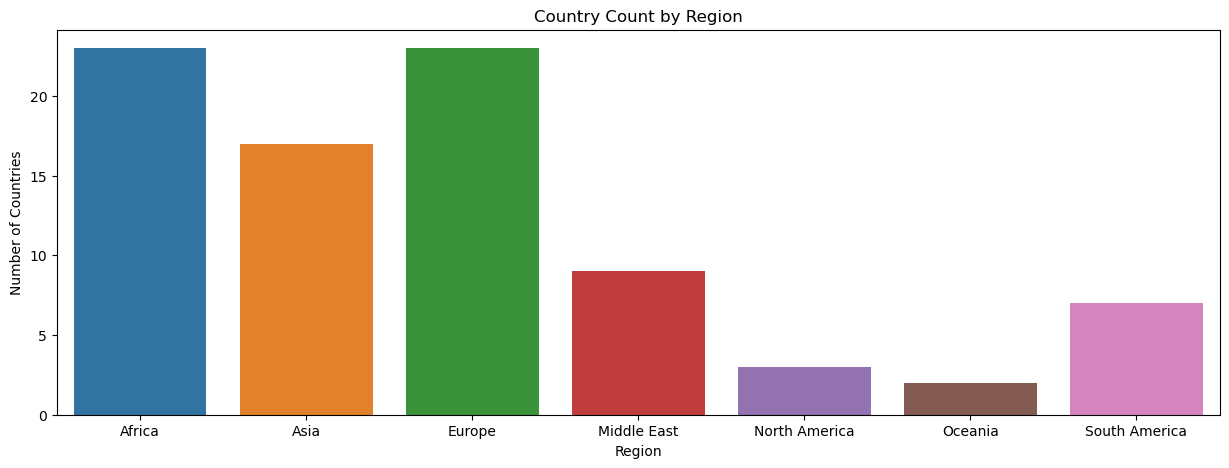

In [16]:
plt.figure(figsize=(15,5))
country_region = df.groupby(by=['region'])['country'].nunique().reset_index(name='count')
sns.barplot(data=country_region, x='region',y='count', hue='region')
plt.xlabel('Region')
plt.ylabel('Number of Countries')
plt.title('Country Count by Region')
plt.show()

I used a barplot to see how many unique countries are present in each region.   
We can see that Africa and Europe have the highest number of countries (23) in the dataset while Oceania has the least.    
This shows that dataset is highly dominated by african and european countries.

### Q) What is the distribution of income_level in the data?

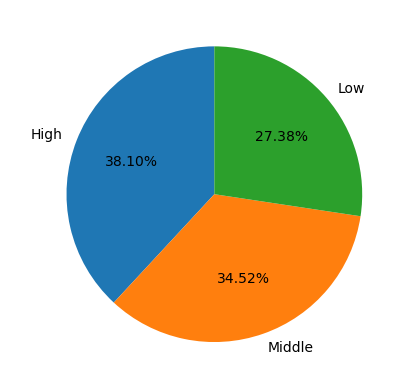

In [17]:
df['income_level'].value_counts().plot.pie(startangle=90,autopct="%.2f%%")
plt.ylabel(' ');
plt.show()

I used a pie chart to see the percentage distribution of each income level in the dataset.  
High income countries make up the largest share at 38.10%, followed by Middle income at 34.52% and Low income at 27.38%.  
The distribution is fairly balanced. 

### Q) What is the distribution of subsidy_level in the data?

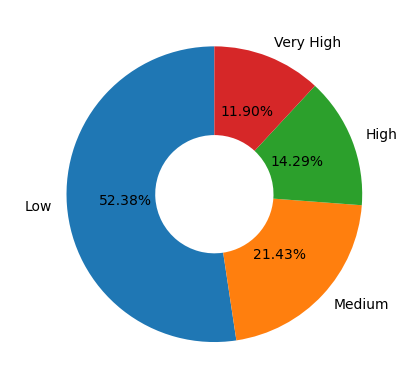

In [18]:
df['subsidy_level'].value_counts().plot.pie(startangle=90,autopct="%.2f%%",wedgeprops=dict(width=0.6))
plt.ylabel(' ');
plt.show()

I used donut plot to visualize the distribution of subsidy_level in the data.  
We can clearly see that the dataset is dominated by low subsidy_level (~52%).  
All other levels are almost equally distributed.   
This tells us that most countries in our dataset do not heavily subsidise fuel.

### Q) What is the distribution of petrol prices per liter (in USD)?

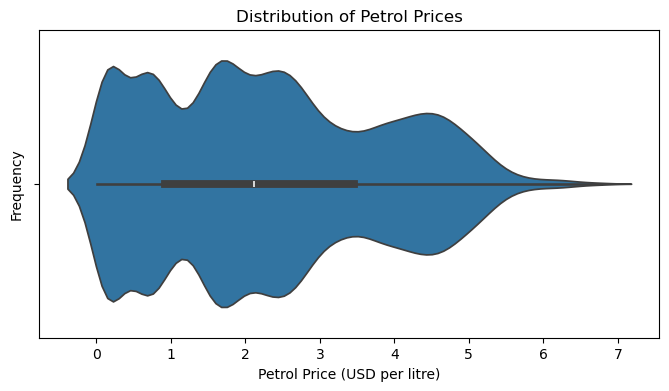

In [19]:
plt.figure(figsize=(8,4))
sns.violinplot(x=df['petrol_usd_liter'])
plt.xlabel('Petrol Price (USD per litre)')
plt.ylabel('Frequency')
plt.title('Distribution of Petrol Prices')
plt.show()

I used a violin plot to visualize the distribution shape and the spread of data at the same time.  
The distribution is multimodal as there are multiple bulges in the violin, this shows that petrol prices cluster around a few common ranges rather than one single value.  
The bulges between 0 to 1 USD and 1.5 to 2.5 USD shows that petrol prices cluster around these two common ranges across countries.    
There is a long tail on the right side, showing that a small number of countries have very high petrol prices. Tail on the right side shows that data is slightly right-shewed.

### Q) What is the distribution of diesel prices per liter (in USD)?

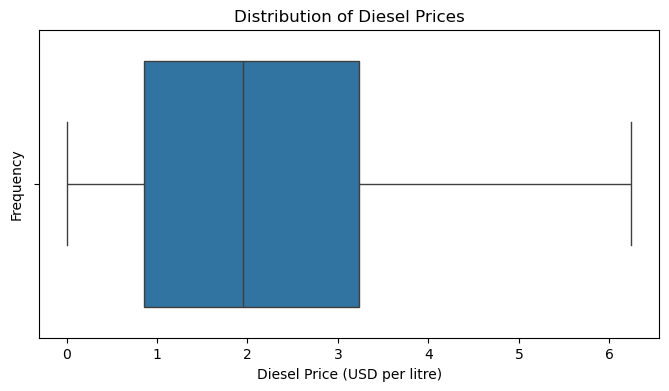

In [20]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['diesel_usd_liter'])
plt.xlabel('Diesel Price (USD per litre)')
plt.ylabel('Frequency')
plt.title('Distribution of Diesel Prices')
plt.show()

I used a boxplot to see the spread and outliers in diesel prices.  
The middle 50% of diesel prices lie approximately between 1 and 3.2 USD per litre, showing moderate variation in prices across countries.    
The right whisker is longer than the left whisker, which shows that the distribution is right-skewed, where a few countries have very high diesel prices.

### Q) What is the distribution of lpg prices per litre (in USD)?

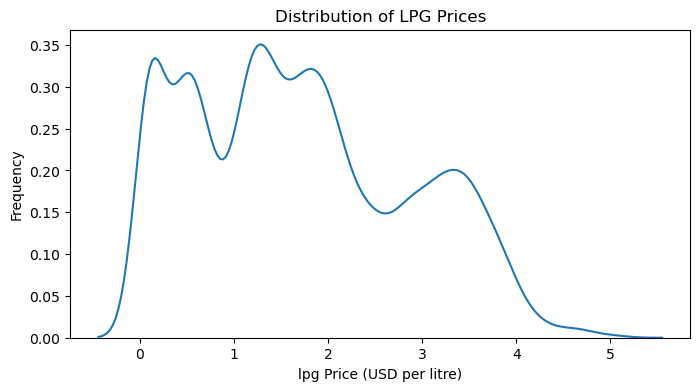

In [21]:
plt.figure(figsize=(8,4))
sns.kdeplot(x=df['lpg_usd_liter'])
plt.xlabel('lpg Price (USD per litre)')
plt.ylabel('Frequency')
plt.title('Distribution of LPG Prices')
plt.show()

I used a KDE plot to visualize LPG price distribution.  
The LPG distribution is multimodal with three visible peaks — around 0.3 USD, 1.3 USD, and 3.3 USD per litre.  
This tells us LPG prices do not follow a single pattern globally, different groups of countries cluster at very different price points.  
The distribution gradually falls off after 4 USD with a right tail.

### Q) What is the distribution of brent crude prices (in USD)?

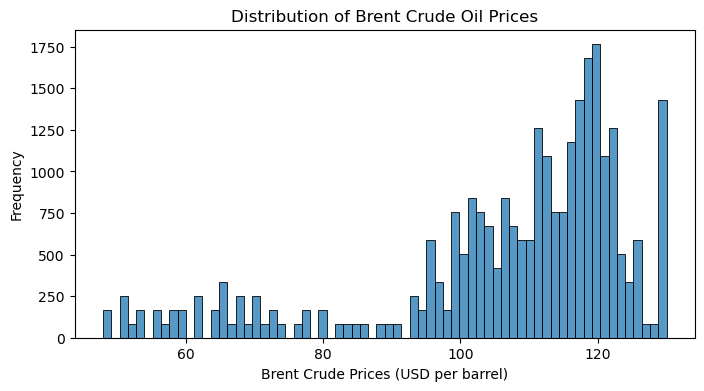

In [22]:
plt.figure(figsize=(8,4))
sns.histplot(x=df['brent_crude_usd'])
plt.xlabel('Brent Crude Prices (USD per barrel)')
plt.ylabel('Frequency')
plt.title('Distribution of Brent Crude Oil Prices')
plt.show()

I used a histogram to see how Brent crude prices are spread.  
The histogram shows that most of the data is concentrated in the 100–130 USD per barrel range — the bars are tallest here, especially near 120 USD. The lower price range (50–90 USD) has much shorter bars, which shows that fewer records exist at those crude prices.   
The distribution is left-skewed as we can see tail on the left side.

### Q) What is the distribution of tax percentage?

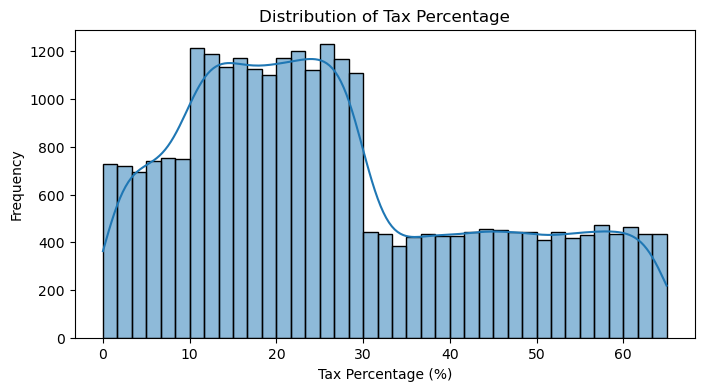

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(x=df['tax_percentage'],kde=True)
plt.xlabel('Tax Percentage (%)')
plt.ylabel('Frequency')
plt.title('Distribution of Tax Percentage')
plt.show()

I used a histogram with a KDE curve to see both the count and shape.  
The distribution is spread across 0% to 65% tax. The bars are relatively uniform in height from 0% to 30%, with the tallest bars appearing around 10–30% — this is where most countries cluster.  
After 30%, the bar heights drop noticeably and stay consistently lower, which shows that fewer countries apply very high taxes.  
The KDE curve peaks around 20–25% and then gradually decreases.   
There are records starting from 0%, meaning some countries have zero or near-zero tax — these are the subsidised nations.

### Q) How does income vary across different region?

In [24]:
income_region = pd.crosstab(df['region'], df['income_level'])
income_region

income_level,High,Low,Middle
region,,,
Africa,0,5559,1962
Asia,1635,1635,2289
Europe,5559,0,1962
Middle East,1635,0,1308
North America,654,0,327
Oceania,654,0,0
South America,327,327,1635


<Figure size 2000x400 with 0 Axes>

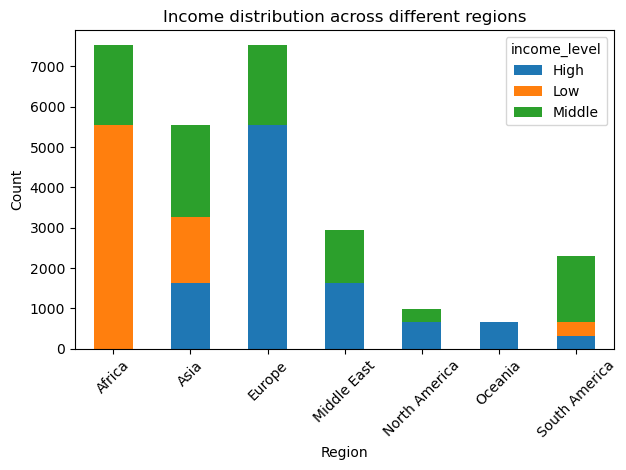

In [25]:
plt.figure(figsize=(20,4))
income_region.plot(kind='bar', stacked=True)
plt.title('Income distribution across different regions')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

I used a stacked bar chart to visualize income level within each region.  
Europe and North America has mostly high income with very less middle income.  
Africa is mostly Low income with very little high income.  
The Middle East is a mix of High and Middle income.  
Asia shows a mix of all three income levels.  
Oceania has only high income level.

### Q) How is income and subsidy related to each other?

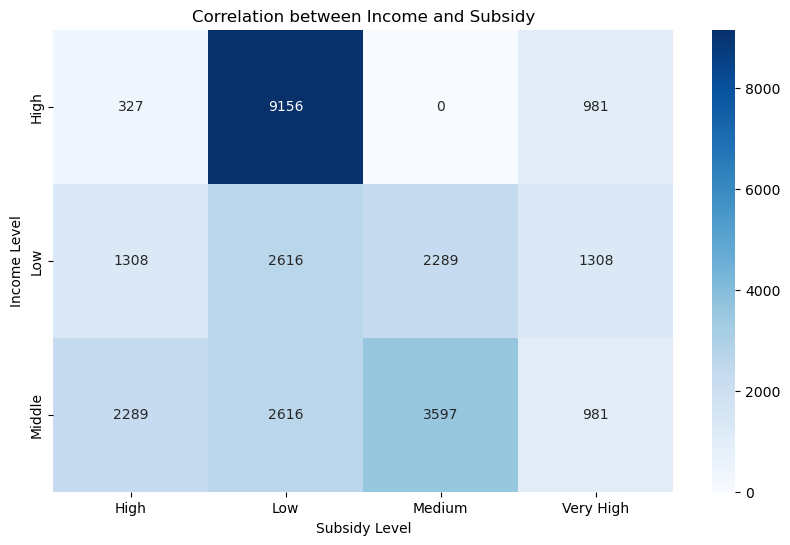

In [26]:
plt.figure(figsize=(10,6))
cross_tab = pd.crosstab(df['income_level'], df['subsidy_level'])
sns.heatmap(cross_tab, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Subsidy Level')
plt.ylabel('Income Level')
plt.title('Correlation between Income and Subsidy')
plt.show()

I used a heatmap on a crosstab to see counts at every combination.  
The darkest cell is High income + Low subsidy with 9156 records, this shows that high income countries prefer low subsidy.  
High income + Medium subsidy is 0, showing that no high income country in the dataset has medium subsidy.  
Low income countries are evenly spread — 1308 High, 2616 Low, 2289 Medium subsidy, showing that there is no consistent policy pattern for low income countries. 

### Q) How subsidy vary across different regions?

In [27]:
subsidy_region = pd.crosstab(df['region'], df['subsidy_level'])
subsidy_region

subsidy_level,High,Low,Medium,Very High
region,,,,
Africa,981,3597,1635,1308
Asia,1308,1962,2289,0
Europe,327,6540,654,0
Middle East,327,654,327,1635
North America,327,654,0,0
Oceania,0,654,0,0
South America,654,327,981,327


<Figure size 2000x400 with 0 Axes>

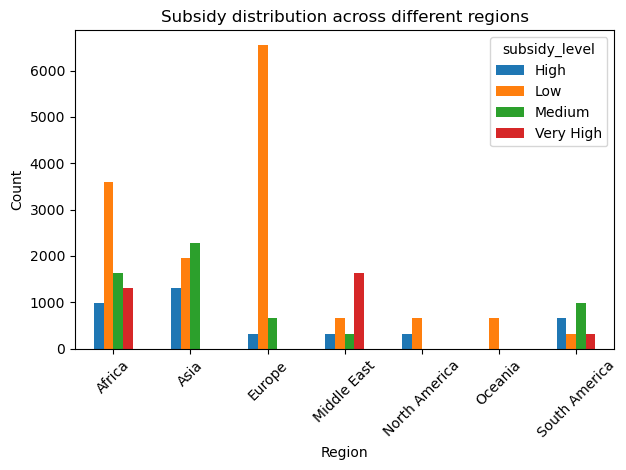

In [28]:
plt.figure(figsize=(20,4))
subsidy_region.plot(kind='bar')
plt.title('Subsidy distribution across different regions')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

I used a grouped bar chart to compare subsidy categories within each region.  
Europe has an extremely dominant Low subsidy bar (~6500) with almost no High or Very High subsidy.  
Africa shows an even spread across Low, High, and Medium subsidy.  
The Middle East stands out with a noticeable Very High subsidy bar.   
Asia shows a strong Medium subsidy.  
This shows subsidy policy is heavily influenced by region — particularly whether a country is an oil producer or not.

### Q) How Petrol price varies with region?

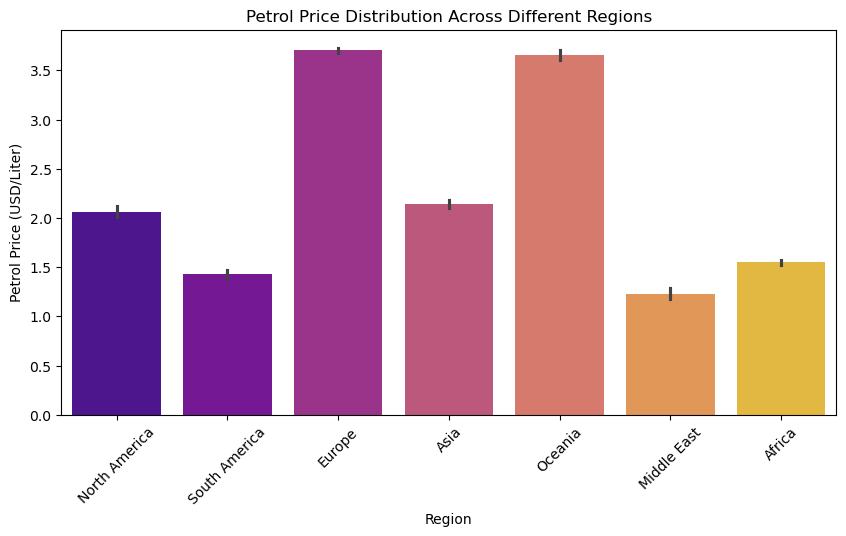

In [29]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='region', y='petrol_usd_liter',palette='plasma')
plt.title('Petrol Price Distribution Across Different Regions')
plt.xlabel('Region')
plt.ylabel('Petrol Price (USD/Liter)')
plt.xticks(rotation=45);
plt.show()

I used a barplot to compare average petrol prices across regions.  
Europe and Oceania have the highest average petrol prices (both around 3.7 USD per litre).  
North America and Asia are in the middle range around 2.1 USD.  
Africa is around 1.6 USD.  
The Middle East has the lowest average petrol price at approximately 1.2 USD per litre.

### Q) How Petrol price vary with subsidy level?

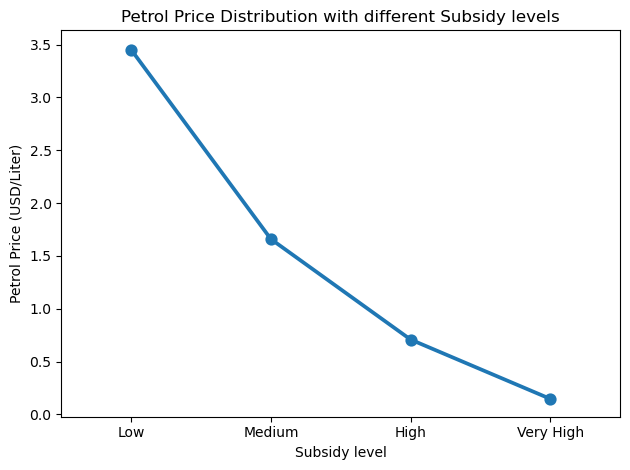

In [30]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.pointplot(data=df, x='subsidy_level', y='petrol_usd_liter', order=order)
plt.title('Petrol Price Distribution with different Subsidy levels')
plt.xlabel('Subsidy level')
plt.ylabel('Petrol Price (USD/Liter)')
plt.tight_layout()
plt.show()

I used a pointplot to show average petrol price at each subsidy level.   
Low subsidy countries have the highest average petrol price at around 3.45 USD.   
High subsidy drops it significantly to around 0.7 USD. Medium subsidy sits at 1.65 USD.  
Very High subsidy brings the price all the way down to around 0.15 USD.  
This confirms that subsidy level is one of the strongest factors affecting pump price.

### Q) How petrol price correlate with brent crude oil price?

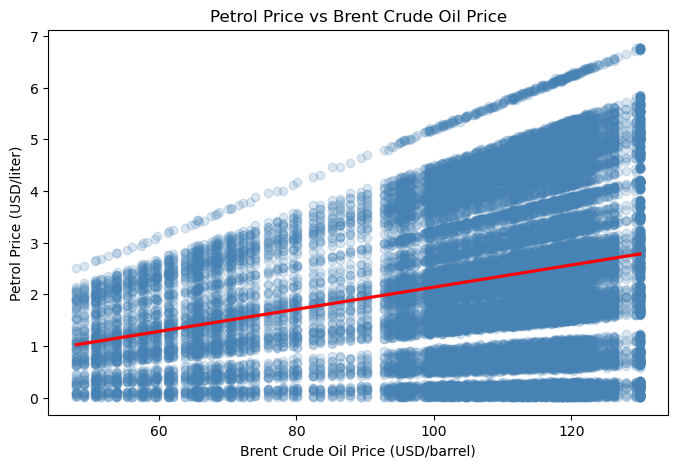

In [31]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='brent_crude_usd', y='petrol_usd_liter', 
            scatter_kws={'alpha':0.2, 'color':'steelblue'}, 
            line_kws={'color':'red'})
plt.xlabel('Brent Crude Oil Price (USD/barrel)')
plt.ylabel('Petrol Price (USD/liter)')
plt.title('Petrol Price vs Brent Crude Oil Price')
plt.show()

I used a regplot with transparent dots and a red regression line to visualize how petrol price coorelates with brent crude oil price.    
We can see that there is a positive relationship between Brent crude oil price and petrol price.  
As Brent crude oil prices increase, petrol prices also tend to increase, which is shown by the red color regression line that has an upward slope, indicating positive correlation between the two variables.     
However, blue data points are widely spread around the regression line, showing that the relationship is moderate rather than very strong.    
Large variation in petrol prices at similar crude oil prices suggests that other factors such as taxes, subsidies and government policies also influence petrol prices.  
Vertical clusters of points indicate that many countries share similar Brent crude oil prices but have different petrol prices.

### Q) How does petrol price correlate with tax percentage?

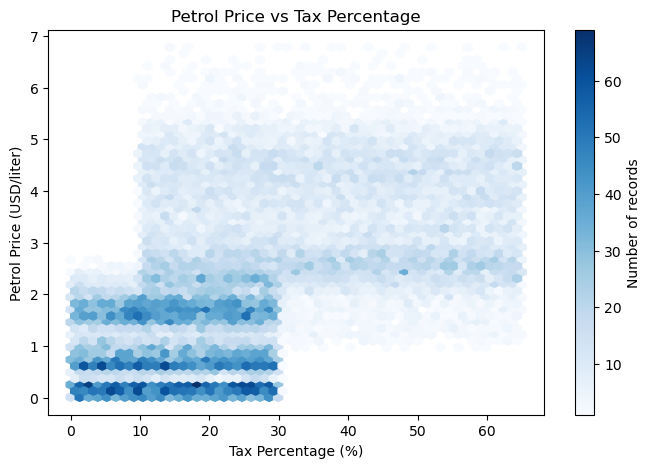

In [32]:
plt.figure(figsize=(8,5))
plt.hexbin(df['tax_percentage'], df['petrol_usd_liter'],gridsize=50, cmap='Blues', mincnt=1)
plt.colorbar(label='Number of records')
plt.xlabel('Tax Percentage (%)')
plt.ylabel('Petrol Price (USD/liter)')
plt.title('Petrol Price vs Tax Percentage')
plt.show()

I used a hexbin plot to visualize the relation between petrolprice and tax percentage.   
Darker blue hexagons represent regions with a higher concentration of records. This shows that most countries in the dataset have tax percentages below 30% and petrol prices between 0 and 2 USD/liter.  
The hexbin plot shows a positive relationship between tax percentage and petrol price. Petrol prices generally tend to increase as tax percentage increases. 
But the relationship is weak because the scatter is wide.   
As tax percentage increases beyond 25%, the hexagons become lighter, meaning fewer countries have very high tax rates.   
Petrol prices vary even at similar tax percentages, indicating that factors other than tax percentage also influence petrol prices.  
The plot also shows dense clusters in lower tax ranges, suggesting that moderate tax percentages are more common in the dataset.

### Q) How does petrol price vary with income level?


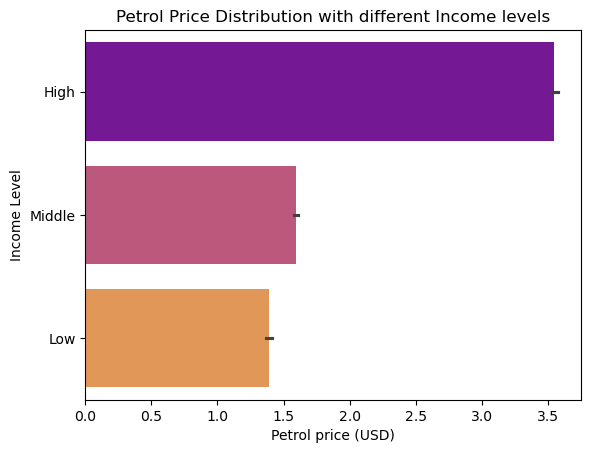

In [33]:
sns.barplot(data=df, x='petrol_usd_liter', y='income_level',palette='plasma')
plt.title('Petrol Price Distribution with different Income levels')
plt.xlabel('Petrol price (USD)')
plt.ylabel('Income Level')
plt.show()

I used a horizontal barplot to compare average petrol prices across income groups.  
We can see that high income countries have by far the highest average petrol price at around 3.5 USD per litre.  
Middle income countries are significantly lower at around 1.6 USD.   
Low income countries are the cheapest at around 1.4 USD.   
The gap between High income and the other two groups is very large, this could be because high income countries impose higher taxes on fuel.   
Low and Middle income are relatively close to each other, showing that income alone does not influence petrol prices.

### Q) How does tax percentage vary across regions?

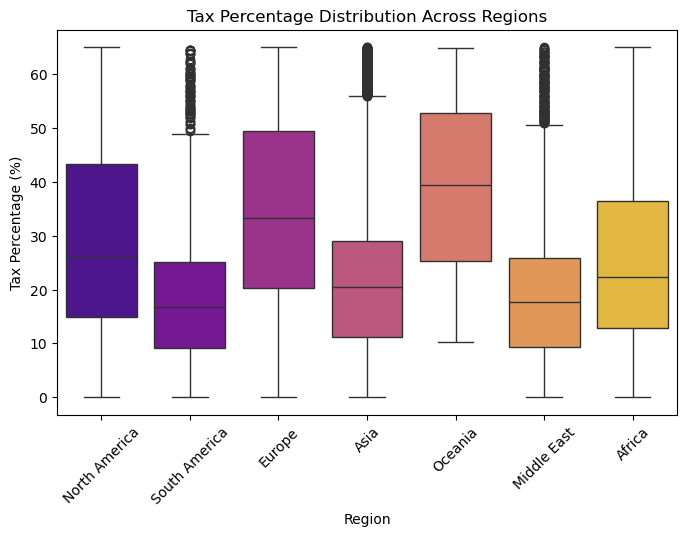

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='region',y='tax_percentage',palette='plasma')
plt.title('Tax Percentage Distribution Across Regions')
plt.xlabel('Region')
plt.ylabel('Tax Percentage (%)')
plt.xticks(rotation=45)
plt.show()

I used a box plot to visualise how tax percentage vary across different regions.  
We can clearly see that tax percentage varies significantly across different regions.  
Oceania has the highest median tax percentage among all regions, indicating generally higher fuel taxes.  
Europe also shows relatively high tax percentages compared to many other regions.  
South America, Asia and Middle East have lower median tax percentages.    
Some regions such as North America, Europe, Oceania, and Africa show wider box ranges, indicating greater variation in tax percentages within those regions.    
Several outliers are present in regions like Asia, South America, and Middle East, suggesting that some countries have unusually high tax percentages compared to others in the same region.  

### Q) How does tax percentage vary with subsidy level?

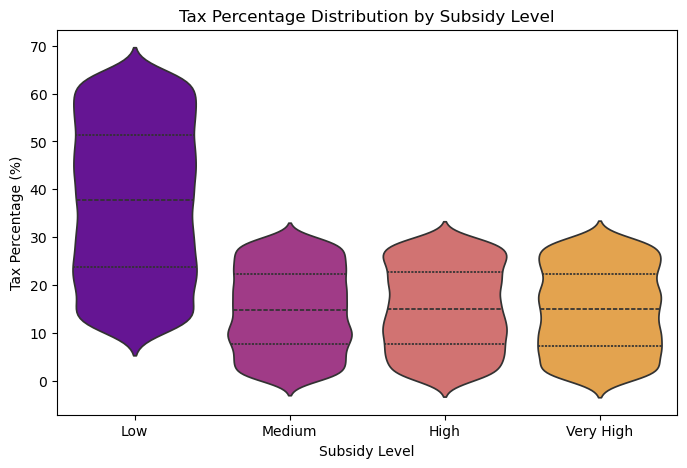

In [35]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='subsidy_level', y='tax_percentage',order=['Low','Medium','High','Very High'], palette='plasma',inner='quartile')
plt.xlabel('Subsidy Level')
plt.ylabel('Tax Percentage (%)')
plt.title('Tax Percentage Distribution by Subsidy Level')
plt.show()

I used a violin plot with quartile lines inside to understand how tax percentage varies across different subsidy levels.  
The Low subsidy violin is the tallest and widest, showing very high variation in tax percentage among countries with low subsidies.  
The wider areas in the violin indicate that many countries have tax percentages concentrated in those ranges.  
Low subsidy countries generally have higher tax percentages compared to other subsidy groups.  
Medium, High and Very High subsidy levels have comparatively lower tax percentage distributions.    
The quartile lines inside the violins show that the median tax percentage is highest for the Low subsidy group.

### Q) How are Petrol, Diesel and LPG prices related?

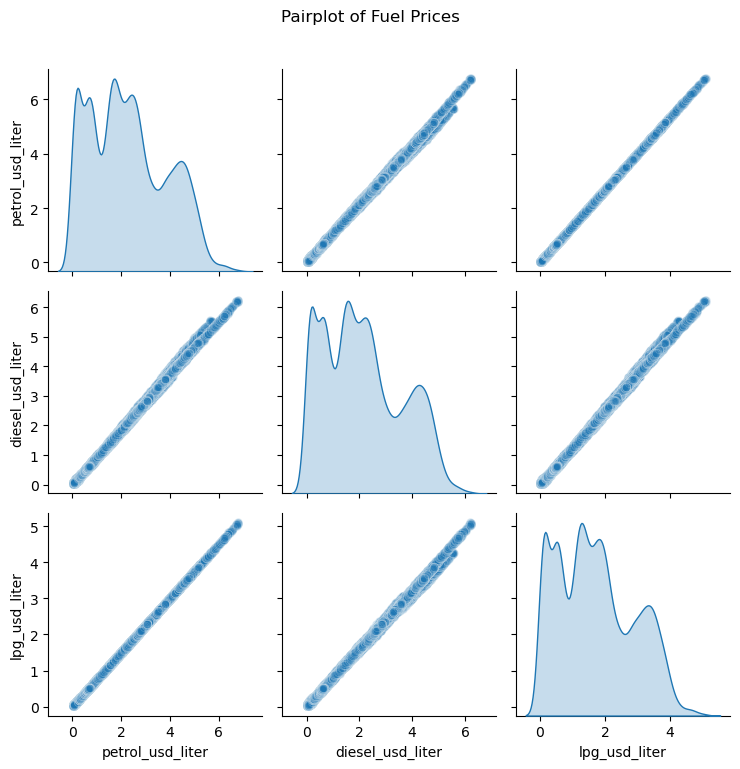

In [36]:
fuel = df[['petrol_usd_liter','diesel_usd_liter','lpg_usd_liter']]
sns.pairplot(fuel, plot_kws={'alpha':0.2}, diag_kind='kde')
plt.suptitle('Pairplot of Fuel Prices', y=1.02)
plt.tight_layout()
plt.show()

I used a pairplot — scatter plots for every pair, KDE on the diagonal.  
The pairplot shows strong positive relationships among petrol, diesel, and LPG prices.  
As the price of one fuel increases, the prices of the other fuels also increase proportionally.  
The scatterplots form nearly straight diagonal patterns, indicating very high correlation between fuel prices.   
The KDE curves on the diagonal show the distribution of individual fuel prices.  
Similar distribution patterns suggest that fuel prices are influenced by common economic and market factors.  
The extremely high correlation among fuel price variables indicates possible multicollinearity, meaning these variables carry very similar information.

### Q) How do income level and subsidy level together affect petrol price?

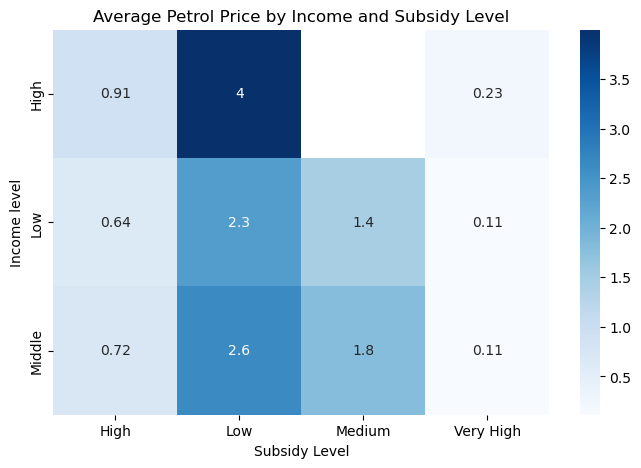

In [37]:
plt.figure(figsize=(8,5))
pivot = df.pivot_table(values='petrol_usd_liter',index='income_level',columns='subsidy_level',aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='Blues')
plt.title('Average Petrol Price by Income and Subsidy Level')
plt.xlabel('Subsidy Level')
plt.ylabel('Income level')
plt.show()

I used a heatmap to visualize how average petrol price varies with each combination of income and subsidy levels.  
We can see that Petrol prices vary significantly based on both income level and subsidy level.  
Countries with low subsidies generally show higher petrol prices across all income groups.  
Countries with high income and low subsidy shows highest petrol prices (darkest cell).  
Very high subsidy levels with middle and low income levels are associated with the lowest petrol prices.  

### Q) Correlation between all numerical features?

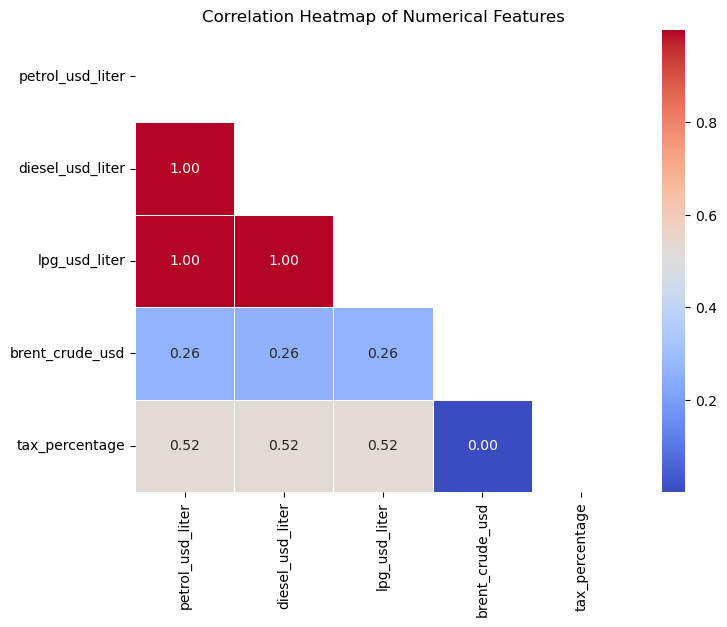

In [38]:
plt.figure(figsize=(8,6))
numeric_cols = ['petrol_usd_liter','diesel_usd_liter','lpg_usd_liter','brent_crude_usd','tax_percentage']
mask = np.triu(np.ones_like(df[numeric_cols].corr(), dtype=bool))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm',fmt='.2f', linewidths=0.5,mask=mask)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

I used a masked correlation heatmap showing only the lower triangle to visualize all numerical features together.  
We can see the Petrol, diesel, and LPG prices show a strong positive correlation (1.00) with each other.  
This shows strong multicollinearity between these variables.  
Brent crude oil price has a weak to moderate positive correlation (0.26) with fuel prices.  
Tax percentage shows a moderate positive correlation (0.52) with fuel prices.  
Tax percentage appears to influence fuel prices more strongly than Brent crude oil price in this dataset.  

---

# LINEAR REGRESSION

## IMPORTING LIBRARIES

In [1]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

## DECLARING TARGET AND FEATURE VARIABLES

In [2]:
# Feature variable
x = df[['region', 'income_level', 'subsidy_level','brent_crude_usd', 'tax_percentage']]

# Target variable
y = df['petrol_usd_liter']

NameError: name 'df' is not defined

Not including diesel and lpg in target variable as these are highly corelated with target variable.

## ENCODING CATEGORICAL DATA
Machine learning models cannot process categorical text directly, so categorical columns were encoded into numerical format.

In [41]:
# Encoding region using Onehot encoder because region does not have any sequence/ranking (nominal data)

ohe = OneHotEncoder(sparse_output=False,drop='first')
region_encoded = pd.DataFrame(
    ohe.fit_transform(x[['region']]),
    columns=ohe.get_feature_names_out(['region']),    # add proper column names
    index=x.index)
x = x.drop('region', axis=1)               # remove original text column
x = pd.concat([x, region_encoded], axis=1) # add the new binary columns


# Encoding income_level using Ordinal encoder because it has ranking(Low < Middle < High) (ordinal data)

oe_income = OrdinalEncoder(categories=[['Low', 'Middle', 'High']])
x[['income_level']] = oe_income.fit_transform(x[['income_level']])


# Encoding subsidy using Ordinal encoder because it has ranking(Low < Medium < High < Very High) (ordinaldata)

oe_subsidy = OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']])
x[['subsidy_level']] = oe_subsidy.fit_transform(x[['subsidy_level']])

## TRAINING AND TESTING MODELS
Performing regression with multiple models and multiple train_test splits using for loops

In [42]:
models = { 'Linear Regression':LinearRegression(),
          'Lasso':Lasso(),
          'Ridge':Ridge(),
          'ElasticNet':ElasticNet()}

split = [0.8,0.7]

result1 = []

for s in split:
    x_train1, x_test1, y_train1, y_test1 = train_test_split(x, y, train_size=s,random_state=42)

    #Scaling was performed to bring all feature values into a similar range
    scaler = StandardScaler()                                   
    x_train_scaled1 = scaler.fit_transform(x_train1) 
    x_test_scaled1 = scaler.transform(x_test1)
    
    for name, model in models.items():
        model.fit(x_train_scaled1,y_train1)      # Training model
        y_pred1 = model.predict(x_test_scaled1)   # Predicting 

        # Evaluation metrics
        R2_Score1 = r2_score(y_test1,y_pred1)       
        MAE1 = mean_absolute_error(y_test1, y_pred1)
        MSE1 = mean_squared_error(y_test1, y_pred1)
        RMSE1 = np.sqrt(MSE1)
        MAPE1 = mean_absolute_percentage_error(y_test1, y_pred1)

        result1.append([f'{int(s*100)}/{round((1-s)*100)}',name,R2_Score1,MAE1,MSE1,RMSE1,MAPE1])

Result1 = pd.DataFrame(result1,columns=['Split','Model','R2_Score','MAE','MSE','RMSE','MAPE'])

for i in Result1['Split'].unique():
    print('\n')
    print('='*80)
    print(f'Train/Test Split : {i}')
    print('='*80)
    print(Result1[Result1['Split'] == i])
    print('\n')



Train/Test Split : 80/20
   Split              Model  R2_Score       MAE       MSE      RMSE      MAPE
0  80/20  Linear Regression  0.888866  0.395193  0.272370  0.521891  1.575578
1  80/20              Lasso  0.251158  1.124337  1.835274  1.354723  4.681381
2  80/20              Ridge  0.888866  0.395192  0.272370  0.521891  1.575347
3  80/20         ElasticNet  0.522552  0.883627  1.170137  1.081729  3.186404




Train/Test Split : 70/30
   Split              Model  R2_Score       MAE       MSE      RMSE      MAPE
4  70/30  Linear Regression  0.886503  0.395554  0.273530  0.523001  1.407368
5  70/30              Lasso  0.252655  1.111172  1.801120  1.342058  4.320503
6  70/30              Ridge  0.886503  0.395553  0.273531  0.523002  1.407135
7  70/30         ElasticNet  0.521252  0.875495  1.153794  1.074148  2.960984




Linear Regression and Ridge achieved high R2 scores in both splits indicating that the model explains nearly 88% of the variance in petrol prices. This may be due to strong relationships among fuel pricing variables, tax percentage, and crude oil prices. Since petrol prices are economically influenced by these factors, the models are able to explain most of the variation in the target variable.    
However, Lasso and ElasticNet is performing poorly in both the splits. R2 scores are very low and high values of other evalution metrics indicates large prediction error.

From the scores we can say that Linear and Ridge are perfroming better than other models.

## ADJUSTED R2 SCORE 
Adjusted R2 score solves the problem of R2 score increasing unnecessarily by adding penalty for unnecessary features because R2 scores tends to increase when you add features even if those are useless features.

In [43]:
n = x_test_scaled1.shape[0]
p = x_test_scaled1.shape[1]

Result1['Adjusted_R2'] = 1 - ((1 - Result1['R2_Score']) * (n - 1) / (n - p - 1))

Result1

,Split,Model,R2_Score,MAE,MSE,RMSE,MAPE,Adjusted_R2
0,80/20,Linear Regression,0.888866,0.395193,0.272370,0.521891,1.575578,0.888731
1,80/20,Lasso,0.251158,1.124337,1.835274,1.354723,4.681381,0.250248
2,80/20,Ridge,0.888866,0.395192,0.272370,0.521891,1.575347,0.888731
3,80/20,ElasticNet,0.522552,0.883627,1.170137,1.081729,3.186404,0.521972
4,70/30,Linear Regression,0.886503,0.395554,0.273530,0.523001,1.407368,0.886365
5,70/30,Lasso,0.252655,1.111172,1.801120,1.342058,4.320503,0.251747
6,70/30,Ridge,0.886503,0.395553,0.273531,0.523002,1.407135,0.886365
7,70/30,ElasticNet,0.521252,0.875495,1.153794,1.074148,2.960984,0.520670


The Adjusted R2 scores are very close to the R2 scores for all regression models, indicating that the selected features contribute meaningfully to predicting petrol prices and do not introduce unnecessary complexity into the model. 

## CROSS VALIDATION  
Cross Validation is a technique used to check how well a model will perform on unseen data.  
Instead of training and testing the model only once, CV trains and tests the model multiple times on different splits of the dataset.

In [44]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet()
}

cv_result = []

for name, model in models.items():
    scores = cross_val_score(model, x_train_scaled1, y_train1, cv=5, scoring='r2')
    cv_result.append([name,scores.mean(),scores.std()])

CV_Result = pd.DataFrame(cv_result,columns=['Model','Mean_CV_Score','Std_Deviation'])

CV_Result

,Model,Mean_CV_Score,Std_Deviation
0,Linear Regression,0.885415,0.001341
1,Ridge,0.885415,0.001341
2,Lasso,0.253300,0.003100
3,ElasticNet,0.520956,0.002337


The Cross Validation results are very close to the train-test split results for all models, showing that the models are stable and generalize well on unseen data. Linear Regression and Ridge consistently achieved the highest performance with low prediction errors and high CV scores, making them the best models for this dataset. Lasso Regression underperformed in both evaluations, while ElasticNet showed moderate results but could not outperform the simpler linear models.

## MODEL COMPARISON PLOT

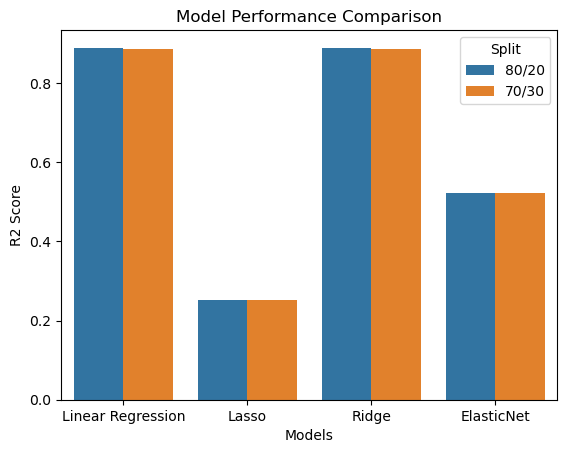

In [45]:
sns.barplot(data=Result1,x='Model',y='R2_Score',hue='Split')
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('R2 Score')
plt.show()

I used a bar plot to compare the performance of all regression models. From the plot, we can clearly see that the R2 scores remained almost the same for both 80/20 and 70/30 train-test splits, which indicates that the models produced consistent results even when the amount of training and testing data changed. This shows that the models are stable and are able to perform well on unseen data without significant variation in accuracy.  
The R2 scores for Linear Regression and Ridge Regression are the highest, which means these models predicted petrol prices more accurately than Lasso and ElasticNet models.

## RESIDUAL PLOT
A residual plot shows the difference between actual and predicted values after the model makes predictions. It helps determine whether the model predictions are appropriate and whether the residuals follow any pattern.

Plotting only for 80/20 split because although the difference is very little, 80/20 gave better scores.

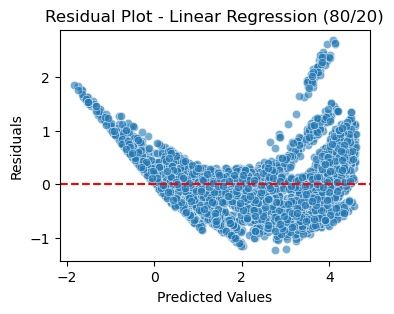

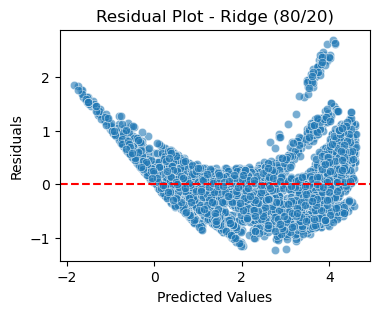

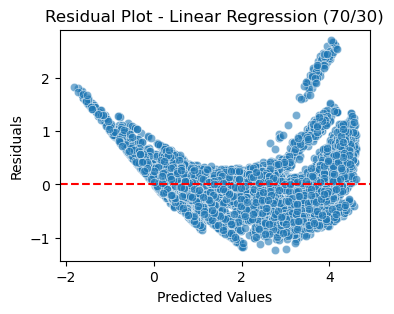

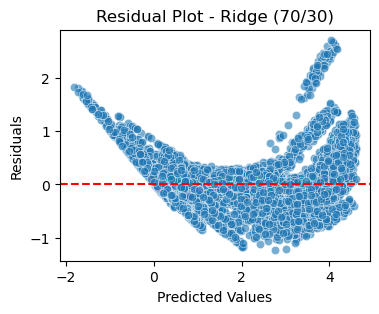

In [46]:
best_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge()}

splits = [0.8, 0.7]

for s in splits:
    x_train1, x_test1, y_train1, y_test1 = train_test_split(x, y,train_size=s,random_state=42)

    scaler = StandardScaler()

    x_train_scaled1 = scaler.fit_transform(x_train1)
    x_test_scaled1 = scaler.transform(x_test1)

    # Residual Plots
    for name, model in best_models.items():
        model.fit(x_train_scaled1, y_train1)    # Train
        y_pred1 = model.predict(x_test_scaled1)   # Predict

        # Residuals
        residuals1 = y_test1 - y_pred1
        
        # Plot
        plt.figure(figsize=(4,3))
        sns.scatterplot(x=y_pred1,y=residuals1,alpha=0.6)
        plt.axhline(y=0, color='red', linestyle='--')
        plt.xlabel('Predicted Values')
        plt.ylabel('Residuals')
        plt.title(f'Residual Plot - {name} ({int(s*100)}/{round((1-s)*100)})')
        plt.show()

Residual plots for a well-fitted model should appear randomly scattered without any visible pattern. However, in the plot shown, we can clearly observe a structured pattern, which indicates the presence of heteroscedasticity. This means the variance of errors is not constant across the range of predictions, violating a key assumption of linear regression.

---

## Applying Log Transformation on the Target Variable (y) and Training–Testing the Model  
Residual plots showed heteroscedasticity, meaning error spread increased with higher values, which violates the constant variance assumption of linear regression.

To fix this, a log transformation was applied to Monthly Revenue (target variable) to reduce the effect of large values, compress the range, and stabilize variance.

In [47]:
# Feature variable
x1 = x

# Target variable
y1 = df['petrol_usd_liter']

In [48]:
y1 = np.log(y1)

In [49]:
models = { 'Linear Regression':LinearRegression(),
          'Lasso':Lasso(),
          'Ridge':Ridge(),
          'ElasticNet':ElasticNet()}

split = [0.8,0.7]

result2 = []

for s in split:
    x_train2, x_test2, y_train2, y_test2 = train_test_split(x1, y1, train_size=s,random_state=42)

    #Scaling was performed to bring all feature values into a similar range
    #for better model performance, especially for Ridge, Lasso, and ElasticNet regression.
    scaler = StandardScaler()                                   
    x_train_scaled2 = scaler.fit_transform(x_train2) 
    x_test_scaled2 = scaler.transform(x_test2)
    
    for name, model in models.items():
        model.fit(x_train_scaled2,y_train2)      # Training model
        y_pred_log2 = model.predict(x_test_scaled2)   # Predicting in log scale

        y_test_actual2 = np.exp(y_test2)
        y_pred_actual2 = np.exp(y_pred_log2)

        # Evaluation metrics on original scale
        R2_Score2 = r2_score(y_test_actual2, y_pred_actual2)
        MAE2 = mean_absolute_error(y_test_actual2, y_pred_actual2)
        MSE2 = mean_squared_error(y_test_actual2, y_pred_actual2)
        RMSE2 = np.sqrt(MSE2)
        MAPE2 = mean_absolute_percentage_error(y_test_actual2, y_pred_actual2)

        result2.append([f'{int(s*100)}/{round((1-s)*100)}',name,R2_Score2,MAE2,MSE2,RMSE2,MAPE2])

Result2 = pd.DataFrame(result2,columns=['Split','Model','R2_Score','MAE','MSE','RMSE','MAPE'])

for i in Result2['Split'].unique():
    print('\n')
    print('='*80)
    print(f'Train/Test Split : {i}')
    print('='*80)
    print(Result2[Result2['Split'] == i])
    print('\n')



Train/Test Split : 80/20
   Split              Model  R2_Score       MAE       MSE      RMSE      MAPE
0  80/20  Linear Regression  0.861534  0.410247  0.339354  0.582541  0.428349
1  80/20              Lasso -0.155821  1.317289  2.832705  1.683064  3.484287
2  80/20              Ridge  0.861578  0.410191  0.339247  0.582449  0.428357
3  80/20         ElasticNet  0.239010  0.986019  1.865045  1.365667  1.883352




Train/Test Split : 70/30
   Split              Model  R2_Score       MAE       MSE      RMSE      MAPE
4  70/30  Linear Regression  0.854034  0.417147  0.351781  0.593111  0.405049
5  70/30              Lasso -0.140439  1.291912  2.748486  1.657856  3.191839
6  70/30              Ridge  0.854086  0.417082  0.351655  0.593005  0.405054
7  70/30         ElasticNet  0.249496  0.964471  1.808731  1.344891  1.730975




After log transformation, Linear Regression and Ridge Regression continued 
to perform well while Lasso and ElasticNet remained poor. 

## ADJUSTED R2 SCORE

In [50]:
n = x_test_scaled2.shape[0]
p = x_test_scaled2.shape[1]

Result2['Adjusted_R2'] = 1 - ((1 - Result2['R2_Score']) * (n - 1) / (n - p - 1))

Result2

,Split,Model,R2_Score,MAE,MSE,RMSE,MAPE,Adjusted_R2
0,80/20,Linear Regression,0.861534,0.410247,0.339354,0.582541,0.428349,0.861366
1,80/20,Lasso,-0.155821,1.317289,2.832705,1.683064,3.484287,-0.157226
2,80/20,Ridge,0.861578,0.410191,0.339247,0.582449,0.428357,0.861410
3,80/20,ElasticNet,0.239010,0.986019,1.865045,1.365667,1.883352,0.238086
4,70/30,Linear Regression,0.854034,0.417147,0.351781,0.593111,0.405049,0.853857
5,70/30,Lasso,-0.140439,1.291912,2.748486,1.657856,3.191839,-0.141825
6,70/30,Ridge,0.854086,0.417082,0.351655,0.593005,0.405054,0.853909
7,70/30,ElasticNet,0.249496,0.964471,1.808731,1.344891,1.730975,0.248585


## RESIDUAL PLOTS FOR BEST MODELS

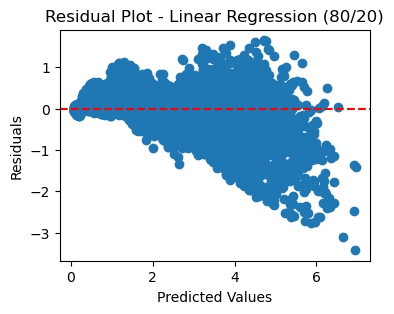

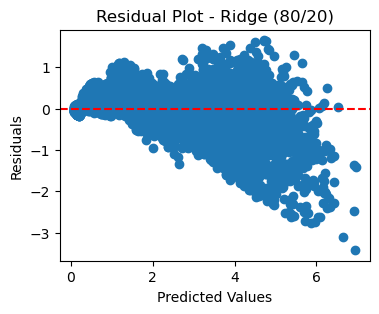

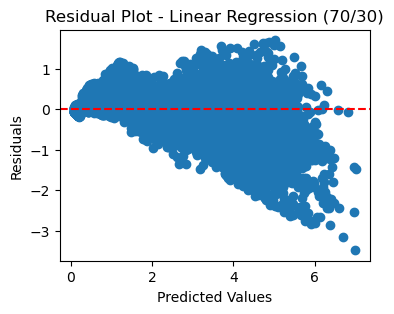

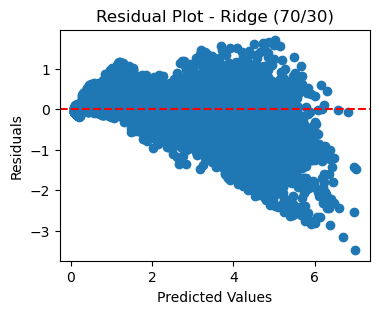

In [51]:
best_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge()}

splits = [0.8, 0.7]

for s in splits:
    x_train2, x_test2, y_train2, y_test2 = train_test_split(x1, y1,train_size=s,random_state=42)

    scaler = StandardScaler()

    x_train_scaled2 = scaler.fit_transform(x_train2)
    x_test_scaled2 = scaler.transform(x_test2)

    # Residual plots
    for name, model in best_models.items():
        model.fit(x_train_scaled2, y_train2)    # Train
        y_pred_log2 = model.predict(x_test_scaled2)    # Predict in log scale

        # Convert back to original scale
        y_test_actual2 = np.exp(y_test2)
        y_pred_actual2 = np.exp(y_pred_log2)

        # Residuals in original scale
        residuals2 = y_test_actual2 - y_pred_actual2

        # Residual Plot
        plt.figure(figsize=(4,3))
        plt.scatter(y_pred_actual2, residuals2)
        plt.axhline(y=0, color='red', linestyle='--')
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals")
        plt.title(f"Residual Plot - {name} ({int(s*100)}/{round((1-s)*100)})")
        plt.show()

## CONCLUSION

Among all regression models, Linear Regression and Ridge Regression showed 
the best performance. The 80/20 train-test split achieved the highest R2 
score with the lowest error metrics. **Ridge Regression with log transformation 
on the target variable and 80/20 split was selected as the final model due 
to its strong performance, improved residuals and stability.**

After applying log transformation to the target variable, residual patterns 
improved and heteroscedasticity reduced. The residuals are not perfectly 
random because this is a real-world global dataset where countries have very 
different petrol prices due to their government policies. These extreme values 
are genuine economic differences between countries and not data errors, so 
removing them was rejected to keep the model realistic and reliable.

---

---

##### Transforming both x and y (if skewed) and checking for R2 scores,other metrics and residual plots.



Train/Test Split : 80/20
   Split              Model  R2_Score     MAE     MSE    RMSE    MAPE
0  80/20  Linear Regression    0.8639  0.4076  0.3335  0.5775  0.4274
1  80/20              Lasso   -0.1558  1.3173  2.8327  1.6831  3.4843
2  80/20              Ridge    0.8640  0.4075  0.3334  0.5774  0.4274
3  80/20         ElasticNet    0.2390  0.9860  1.8650  1.3657  1.8834




Train/Test Split : 70/30
   Split              Model  R2_Score     MAE     MSE    RMSE    MAPE
4  70/30  Linear Regression    0.8565  0.4143  0.3458  0.5881  0.4044
5  70/30              Lasso   -0.1404  1.2919  2.7485  1.6579  3.1918
6  70/30              Ridge    0.8566  0.4142  0.3457  0.5880  0.4044
7  70/30         ElasticNet    0.2495  0.9645  1.8087  1.3449  1.7310




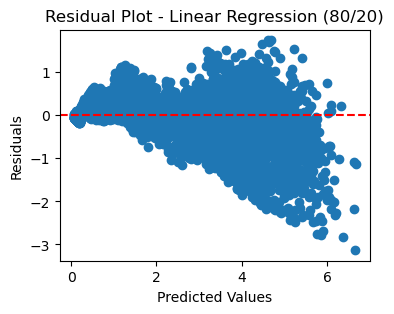

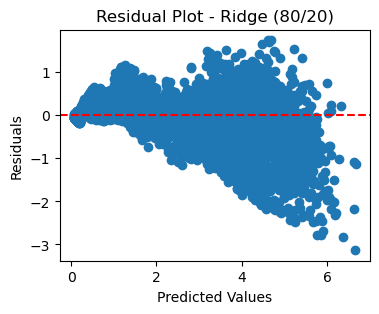

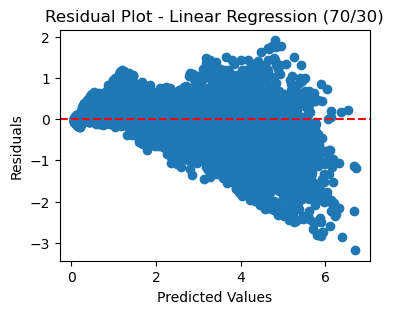

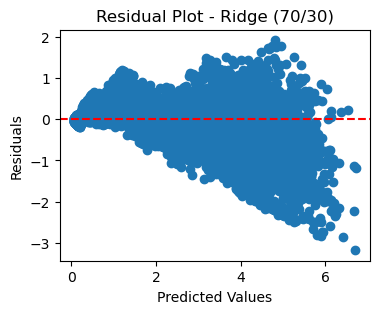

In [52]:
# -------------------------------
# Model 3 : X and Y Transformation
# -------------------------------

# Feature variables
x3 = df[['region','income_level','subsidy_level','brent_crude_usd','tax_percentage']]

# Target variable
y3 = np.log(df['petrol_usd_liter'])

# -------------------------------
# Log Transformation on X
# -------------------------------

x3['brent_crude_usd'] = np.log1p(x3['brent_crude_usd'])

# -------------------------------
# Encoding
# -------------------------------

# One Hot Encoding : region
ohe3 = OneHotEncoder(
    sparse_output=False,
    drop='first')

region_encoded3 = pd.DataFrame(
    ohe3.fit_transform(x3[['region']]),
    columns=ohe3.get_feature_names_out(['region']),
    index=x3.index)

x3 = x3.drop('region', axis=1)

x3 = pd.concat([x3, region_encoded3], axis=1)

# Ordinal Encoding : income_level
oe_income3 = OrdinalEncoder(
    categories=[['Low', 'Middle', 'High']])

x3[['income_level']] = oe_income3.fit_transform(
    x3[['income_level']])

# Ordinal Encoding : subsidy_level
oe_subsidy3 = OrdinalEncoder(
    categories=[['Low', 'Medium', 'High', 'Very High']])

x3[['subsidy_level']] = oe_subsidy3.fit_transform(
    x3[['subsidy_level']])

# -------------------------------
# Model Training
# -------------------------------

models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'ElasticNet': ElasticNet()}

split = [0.8, 0.7]

result3 = []

for s in split:

    # Train-Test Split
    x_train3, x_test3, y_train3, y_test3 = train_test_split(x3,y3,train_size=s,random_state=42)

    # Scaling
    scaler = StandardScaler()

    x_train_scaled3 = scaler.fit_transform(x_train3)
    x_test_scaled3 = scaler.transform(x_test3)

    for name, model in models.items():

        # Train
        model.fit(x_train_scaled3, y_train3)

        # Prediction in log scale
        y_pred_log3 = model.predict(x_test_scaled3)

        # Convert back to original scale
        y_test_actual3 = np.exp(y_test3)
        y_pred_actual3 = np.exp(y_pred_log3)

        # Evaluation Metrics
        R2_Score3 = r2_score(y_test_actual3,y_pred_actual3)
        MAE3 = mean_absolute_error(y_test_actual3,y_pred_actual3)
        MSE3 = mean_squared_error(y_test_actual3,y_pred_actual3)
        RMSE3 = np.sqrt(MSE3)
        MAPE3 = mean_absolute_percentage_error(y_test_actual3,y_pred_actual3)

        result3.append([f'{int(s*100)}/{round((1-s)*100)}',name,R2_Score3,MAE3,MSE3,RMSE3,MAPE3])

# -------------------------------
# Result DataFrame
# -------------------------------

Result3 = pd.DataFrame(result3,columns=['Split','Model','R2_Score','MAE','MSE','RMSE','MAPE'])

Result3 = Result3.round(4)

# Display Results
for i in Result3['Split'].unique():
    print('\n')
    print('='*80)
    print(f'Train/Test Split : {i}')
    print('='*80)
    print(Result3[Result3['Split'] == i])
    print('\n')

# -------------------------------
# Residual Plots for Best Models
# -------------------------------

best_models3 = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge()}

for s in split:

    # Train-Test Split
    x_train3, x_test3, y_train3, y_test3 = train_test_split(x3,y3,train_size=s,random_state=42)

    # Scaling
    scaler = StandardScaler()

    x_train_scaled3 = scaler.fit_transform(x_train3)
    x_test_scaled3 = scaler.transform(x_test3)

    for name, model in best_models3.items():

        # Train
        model.fit(x_train_scaled3, y_train3)

        # Prediction in log scale
        y_pred_log3 = model.predict(x_test_scaled3)

        # Convert back to original scale
        y_test_actual3 = np.exp(y_test3)
        y_pred_actual3 = np.exp(y_pred_log3)

        # Residuals
        residuals3 = y_test_actual3 - y_pred_actual3

        # Residual Plot
        plt.figure(figsize=(4,3))

        plt.scatter(y_pred_actual3, residuals3)
        plt.axhline(y=0,color='red',linestyle='--')
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals")
        plt.title(f"Residual Plot - {name} ({int(s*100)}/{round((1-s)*100)})")
        plt.show()

In [53]:
n = x_test_scaled3.shape[0]
p = x_test_scaled3.shape[1]

Result3['Adjusted_R2'] = 1 - ((1 - Result3['R2_Score']) * (n - 1) / (n - p - 1))

Result3

,Split,Model,R2_Score,MAE,MSE,RMSE,MAPE,Adjusted_R2
0,80/20,Linear Regression,0.8639,0.4076,0.3335,0.5775,0.4274,0.863735
1,80/20,Lasso,-0.1558,1.3173,2.8327,1.6831,3.4843,-0.157204
2,80/20,Ridge,0.8640,0.4075,0.3334,0.5774,0.4274,0.863835
3,80/20,ElasticNet,0.2390,0.9860,1.8650,1.3657,1.8834,0.238075
4,70/30,Linear Regression,0.8565,0.4143,0.3458,0.5881,0.4044,0.856326
5,70/30,Lasso,-0.1404,1.2919,2.7485,1.6579,3.1918,-0.141786
6,70/30,Ridge,0.8566,0.4142,0.3457,0.5880,0.4044,0.856426
7,70/30,ElasticNet,0.2495,0.9645,1.8087,1.3449,1.7310,0.248588
